In [4]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

resultado01.pgm: As imagens são idênticas pixel a pixel
resultado01.pgm: Diferentes: 0 pixels (0.0000% do total)
resultado01.pgm: Maior diferença: 0
resultado01.pgm: Primeiros pixels diferentes (linha, coluna):
[]


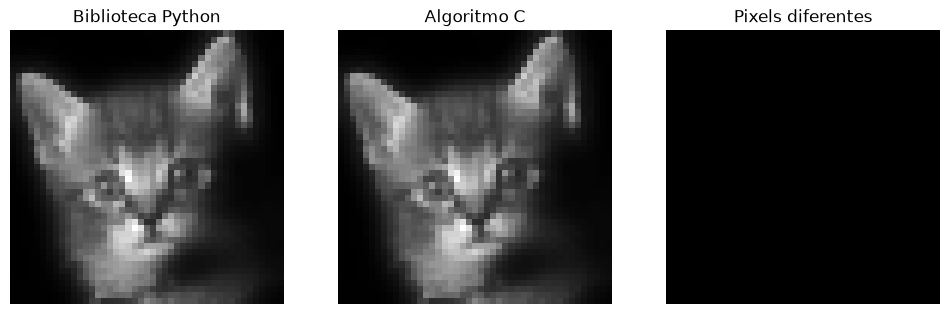

resultado02.pgm: Diferentes: 487 pixels (24.0494% do total)
resultado02.pgm: Maior diferença: 8
resultado02.pgm: Primeiros pixels diferentes (linha, coluna):
[[0 0]
 [0 1]
 [0 2]
 [0 3]
 [0 4]
 [0 5]
 [0 6]
 [0 7]
 [0 8]
 [0 9]]


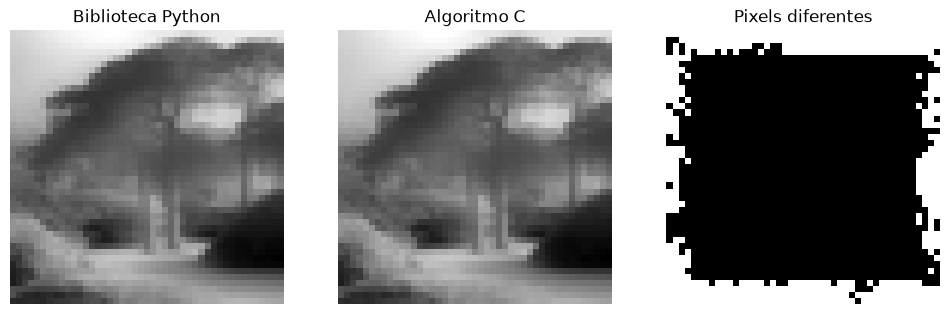

resultado03.pgm: Diferentes: 264 pixels (13.0370% do total)
resultado03.pgm: Maior diferença: 6
resultado03.pgm: Primeiros pixels diferentes (linha, coluna):
[[ 0 12]
 [ 0 13]
 [ 0 14]
 [ 0 15]
 [ 0 16]
 [ 0 17]
 [ 0 18]
 [ 0 19]
 [ 0 20]
 [ 0 21]]


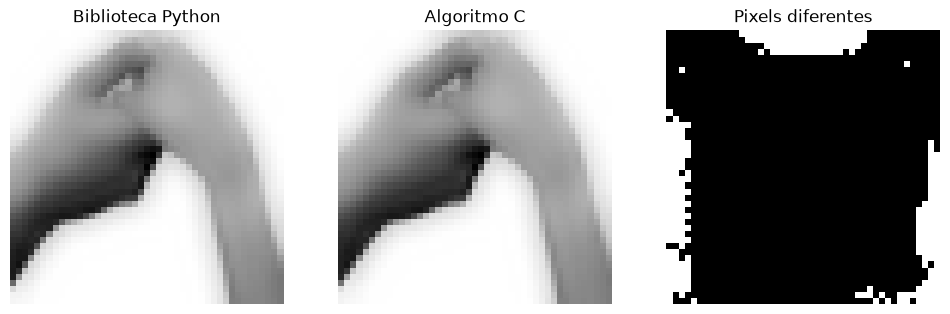

resultado04.pgm: Diferentes: 345 pixels (17.0370% do total)
resultado04.pgm: Maior diferença: 5
resultado04.pgm: Primeiros pixels diferentes (linha, coluna):
[[ 0  0]
 [ 0  1]
 [ 0  3]
 [ 0  4]
 [ 0  5]
 [ 0  6]
 [ 0  7]
 [ 0  8]
 [ 0  9]
 [ 0 10]]


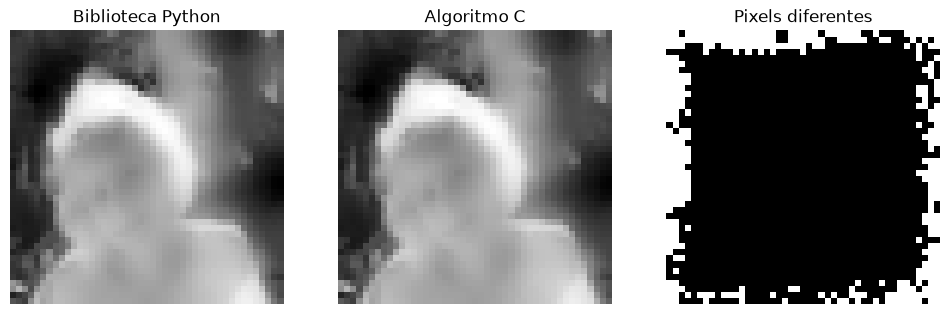

resultado05.pgm: Diferentes: 329 pixels (16.2469% do total)
resultado05.pgm: Maior diferença: 4
resultado05.pgm: Primeiros pixels diferentes (linha, coluna):
[[ 0  1]
 [ 0  2]
 [ 0  3]
 [ 0  4]
 [ 0  5]
 [ 0  6]
 [ 0  7]
 [ 0  8]
 [ 0  9]
 [ 0 10]]


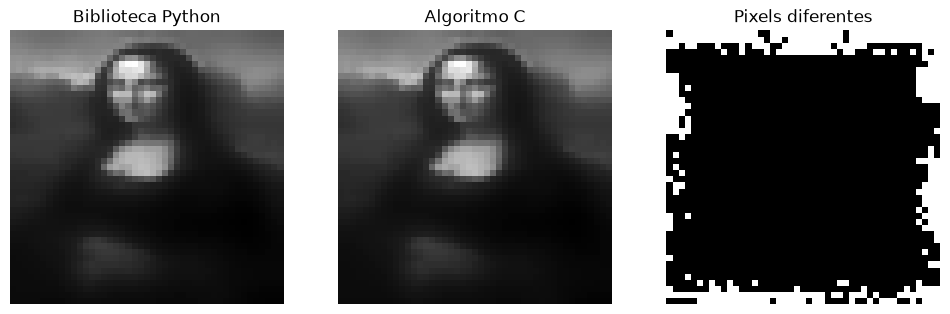

resultado06.pgm: Diferentes: 477 pixels (23.5556% do total)
resultado06.pgm: Maior diferença: 6
resultado06.pgm: Primeiros pixels diferentes (linha, coluna):
[[ 0  0]
 [ 0  1]
 [ 0  2]
 [ 0  3]
 [ 0  5]
 [ 0  6]
 [ 0  7]
 [ 0 10]
 [ 0 11]
 [ 0 12]]


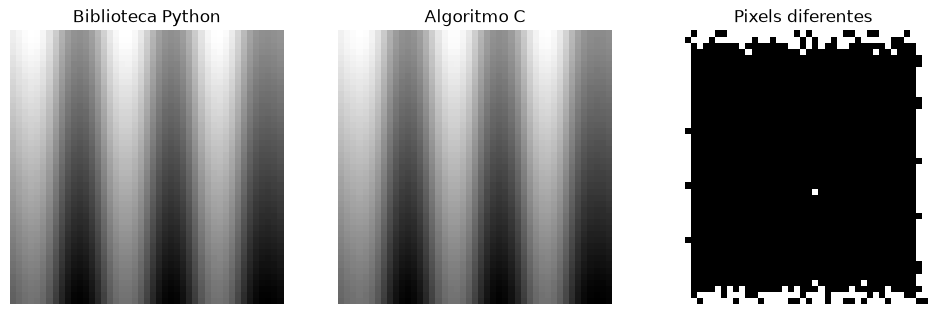

resultado07.pgm: Diferentes: 475 pixels (23.4568% do total)
resultado07.pgm: Maior diferença: 9
resultado07.pgm: Primeiros pixels diferentes (linha, coluna):
[[ 0  0]
 [ 0  1]
 [ 0  2]
 [ 0  3]
 [ 0  4]
 [ 0  5]
 [ 0  6]
 [ 0  7]
 [ 0  9]
 [ 0 10]]


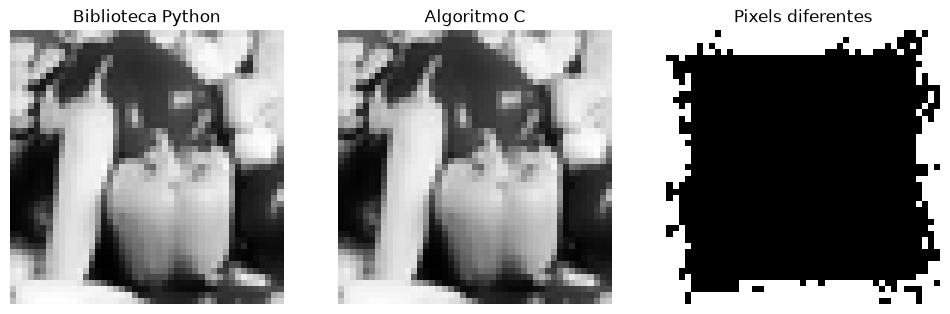

resultado08.pgm: Diferentes: 343 pixels (16.9383% do total)
resultado08.pgm: Maior diferença: 12
resultado08.pgm: Primeiros pixels diferentes (linha, coluna):
[[ 0  0]
 [ 0  1]
 [ 0  2]
 [ 0  3]
 [ 0  7]
 [ 0  8]
 [ 0  9]
 [ 0 10]
 [ 0 11]
 [ 0 12]]


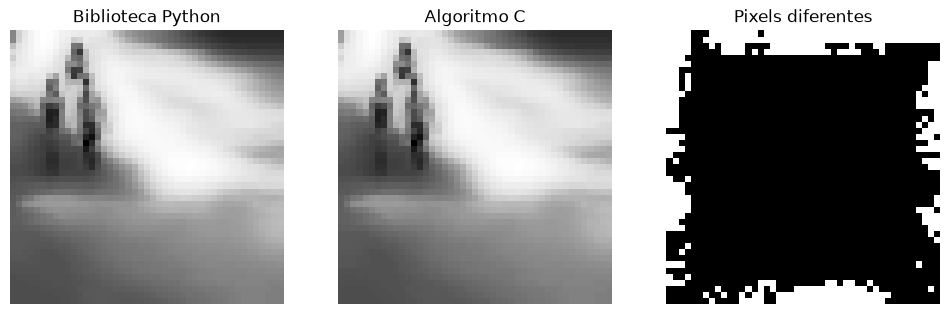

resultado09.pgm: Diferentes: 436 pixels (21.5309% do total)
resultado09.pgm: Maior diferença: 6
resultado09.pgm: Primeiros pixels diferentes (linha, coluna):
[[0 0]
 [0 1]
 [0 2]
 [0 3]
 [0 4]
 [0 5]
 [0 6]
 [0 7]
 [0 8]
 [0 9]]


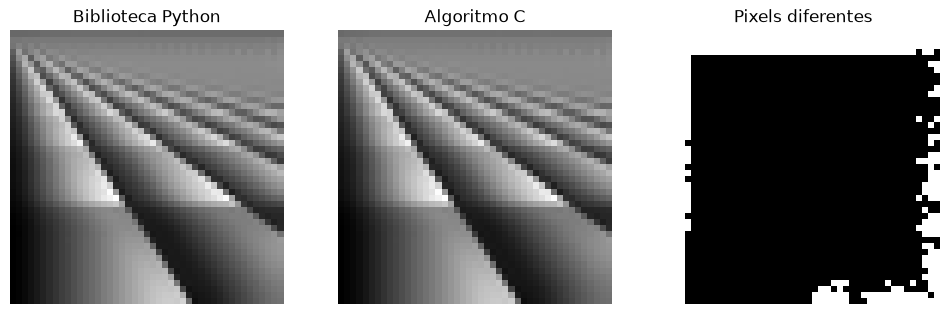

resultado10.pgm: Diferentes: 226 pixels (11.1605% do total)
resultado10.pgm: Maior diferença: 3
resultado10.pgm: Primeiros pixels diferentes (linha, coluna):
[[ 0  1]
 [ 1  1]
 [ 2  1]
 [ 3  1]
 [ 3 26]
 [ 4  1]
 [ 4 25]
 [ 5  1]
 [ 5 44]
 [ 6  1]]


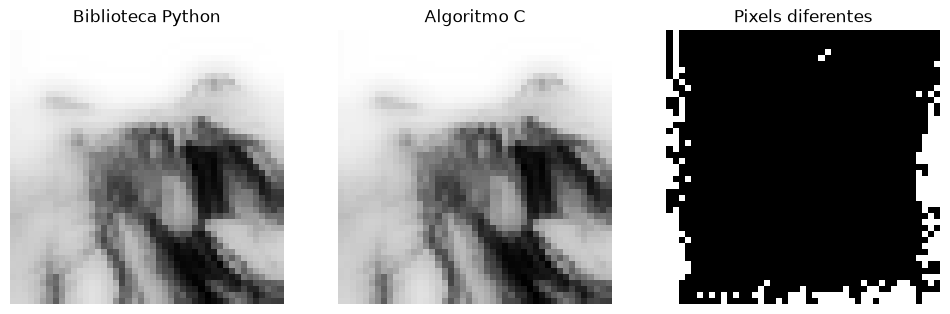

resultado11.pgm: Diferentes: 179 pixels (8.8395% do total)
resultado11.pgm: Maior diferença: 4
resultado11.pgm: Primeiros pixels diferentes (linha, coluna):
[[10  1]
 [13  0]
 [13  1]
 [13 43]
 [13 44]
 [14  0]
 [14  1]
 [15  1]
 [15  2]
 [15  3]]


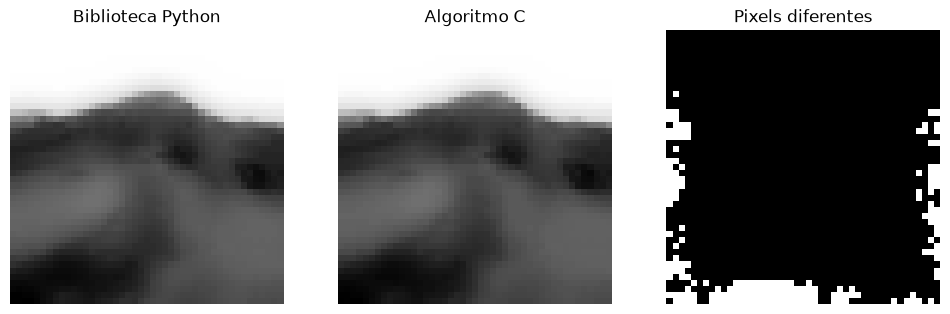

resultado12.pgm: Diferentes: 244 pixels (12.0494% do total)
resultado12.pgm: Maior diferença: 4
resultado12.pgm: Primeiros pixels diferentes (linha, coluna):
[[ 0  7]
 [ 0 12]
 [ 0 13]
 [ 0 15]
 [ 0 16]
 [ 0 17]
 [ 0 19]
 [ 0 21]
 [ 0 27]
 [ 0 35]]


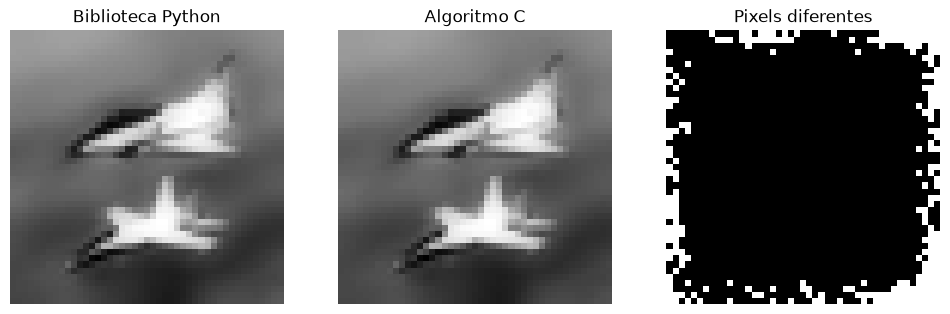

In [9]:
for filename in os.listdir("images_pgm_c_filtradas"):
    if filename.endswith(".pgm"):
        output_actual = cv2.imread(os.path.join("images_pgm_c_filtradas", filename), cv2.IMREAD_GRAYSCALE)
        output_expected = cv2.imread(os.path.join("images_pgm_py_filtradas", filename), cv2.IMREAD_GRAYSCALE)

        if output_expected.shape != output_actual.shape:
            print(f"{filename}: Diferentes: dimensões distintas")
        elif output_expected.dtype != output_actual.dtype:
            print(f"{filename}: Diferentes: tipos de dado distintos (ex.: 8 vs 16 bits)")
        elif np.array_equal(output_expected, output_actual):
            print(f"{filename}: As imagens são idênticas pixel a pixel")
        mask = output_expected != output_actual
        n_diff = mask.sum()
        print(f"{filename}: Diferentes: {n_diff} pixels ({100 * n_diff / mask.size:.4f}% do total)")

        # diferença absoluta em tipo maior, para evitar overflow do uint8
        diff = np.abs(output_expected.astype(np.int32) - output_actual.astype(np.int32))
        print(f"{filename}: Maior diferença:", diff.max())

        coords = np.argwhere(mask)
        print(f"{filename}: Primeiros pixels diferentes (linha, coluna):")
        print(coords[:10])

        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        axes[0].imshow(output_expected, cmap="gray"); axes[0].set_title("Biblioteca Python")
        axes[1].imshow(output_actual, cmap="gray"); axes[1].set_title("Algoritmo C")
        axes[2].imshow(mask, cmap="gray"); axes[2].set_title("Pixels diferentes")
        for ax in axes:
            ax.axis("off")
        plt.show()
